## Reading the file data

In [1]:
# Function to read the input file
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Read column names from the .names file
df_names = pd.read_csv('./dataset/question_4/musk/clean1.names', sep= ':', skiprows=1, header=None)
feature_list = df_names[0].tolist()
column_list = feature_list + ['class_label']

# Read data from the .data file
df_data = pd.read_csv('./dataset/question_4/musk/clean1.data', names=column_list, index_col=False)

# Converting column having categorical values using Label encoder
# Create encoders
molecule_encoder = LabelEncoder()
conformation_encoder = LabelEncoder()

# Convert molecule_name to numeric
df_data['molecule_name'] = molecule_encoder.fit_transform(
    df_data['molecule_name']
)

# Convert conformation_name to numeric
df_data['conformation_name'] = conformation_encoder.fit_transform(
    df_data['conformation_name']
)

dataset_name = 'Clean'

## Note: Please uncomment this code block if you want to use vehicle dataset

In [2]:
# # Function to read the input file
# import pandas as pd

# df_data = pd.read_csv('./dataset/question_4/vehicle/vehicle.dat', sep=r'\s+', header=None)

# # Adding Features on the dataset since we don't have provided feature file for this dataset
# feature_list = [f'feature{i}' for i in range(1, 19)]
# df_data.columns = feature_list + ['class_label']
# dataset_name = 'Vehicle'

In [3]:
# Now, we have read the data file successfully and assign header too after reading the name file
df_data

,molecule_name,conformation_name,f1,f2,f3,f4,f5,f6,f7,f8,...,f158,f159,f160,f161,f162,f163,f164,f165,f166,class_label
0,0,0,42,-198,-109,-75,-117,11,23,-88,...,-74,-129,-120,-38,30,48,-37,6,30,1.0
1,0,1,42,-191,-142,-65,-117,55,49,-170,...,-302,60,-120,-39,31,48,-37,5,30,1.0
2,0,2,42,-191,-142,-75,-117,11,49,-161,...,-73,-127,-120,-38,30,48,-37,5,31,1.0
3,0,3,42,-198,-110,-65,-117,55,23,-95,...,-302,60,-120,-39,30,48,-37,6,30,1.0
4,1,4,42,-198,-102,-75,-117,10,24,-87,...,-73,-127,51,128,144,43,-30,14,26,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,91,471,49,-199,-161,29,-95,-86,-48,2,...,-246,-209,33,152,134,47,-43,-15,-10,0.0
472,91,472,38,-123,-139,30,-117,-88,214,-13,...,-226,-210,20,55,119,79,-28,4,74,0.0
473,91,473,43,-102,-20,-101,-116,200,-166,66,...,32,136,-15,143,121,55,-37,-19,-36,0.0
474,91,474,39,-58,27,31,-117,-92,85,21,...,-232,-206,13,45,116,79,-28,3,74,0.0


## Importing the Required packages

In [4]:
import random
import math
import numpy as np
import time
from deap import base, creator, tools, algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [5]:
# Mantaining the size of individual chromosome to be equal to the number of features present in the dataset
IND_SIZE = len(feature_list)
# Defining the Population size for the Genetic Algorithm
POPULATION_SIZE = 50
# Defining the number of generations for the Genetic Algorithm
NUM_OF_GENERATION = 100
# Crossover Probability
CROSSOVER_PROBABILITY = 0.95
# Mutation Probability
MUTATION_PROBABILITY = 0.2

### Helper functions

In [6]:
# Function to perform mutation on a child individual
def mutate_child(child):
    # Perform flip mutation on the child
    index = random.randrange(len(child))
    child[index] = 1 - child[index]
    return (child,)

# Function to get selected feature list from individual chromosome list
def get_selected_features(individual):
     # List to store selected_feature list
    selected_features = list()

    # 1. Iterating over the individual chromosome to found the feature selected or not
    for index, item in enumerate(individual):
        # This mean this feature is selected
        if item == 1:
            selected_features.append(feature_list[index])

    return selected_features

# Classifier for Checking Accuracy of the Best Individual
def classify_selected_features(df, selected_features):
    # Extract selected features
    X = df[selected_features]

    # Extract class label
    y = df['class_label']

    # Create classifier
    classifier = DecisionTreeClassifier()

    # Train classifier on the entire dataset
    classifier.fit(X, y)

    # Predict on the same dataset
    y_pred = classifier.predict(X)

    # Calculate training accuracy
    accuracy = accuracy_score(y, y_pred)

    return accuracy

# Helper function to check accuracy for a dataframe with selected feature list using train test split
def check_accuracy_with_train_test_split(df, selected_features):
    
    # Extract selected features
    X = df[selected_features]

    # Extract class label
    y = df['class_label']

    # Split dataset into training and testing data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Create classifier
    classifier = DecisionTreeClassifier()

    # Train classifier on training data
    classifier.fit(X_train, y_train)

    # Predict on test data
    y_pred = classifier.predict(X_test)

    # Calculate test accuracy
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy


# Wrapper based: Evaluation Strategy for each individual chromosome in the population
def do_evaluation(individual):
   
    # 1. Iterating over the individual chromosome to found the feature selected or not
    selected_features = get_selected_features(individual)

    if(len(selected_features) == 0):
        return (1.0,1.0)

    # 2. Checking accuracy with Decision Tree classifier
    accuracy = classify_selected_features(df_data, selected_features)
    # accuracy = check_accuracy_with_train_test_split(df_data, selected_features)
    

    #3: Selected Feature Ratio
    selected_feature_ratio = len(selected_features)/len(individual)
    #4: Classification Error Ratio
    classification_error_ratio = 1 - accuracy
    
    return (classification_error_ratio, selected_feature_ratio)

In [7]:
# Calculate Hypervolume
# ---------------------------------------------------------
    
# Reference point for both minimisation objectives
REFERENCE_POINT = (1.0, 1.0)
    
    
def calculate_2d_hypervolume(points, reference_point=(1.0, 1.0)):
    
    # Remove duplicate objective points
    points = list(set(points))
    
    # Sort by classification error (x-axis)
    points.sort(key=lambda p: p[0])
    
    hypervolume = 0.0
    
    reference_x, reference_y = reference_point
    
    for i in range(len(points)):
        x = points[i][0]
        y = points[i][1]
    
        # Next x-coordinate or reference point
        if i + 1 < len(points):
            next_x = points[i + 1][0]
        else:
            next_x = reference_x
    
        width = next_x - x
        height = reference_y - y
    
        if width > 0 and height > 0:
            hypervolume += width * height
    
    return hypervolume

### Registering Functions and Creating Types

In [8]:
# Creating Fitness and Individual Class
creator.create("FitnessMulti", base.Fitness, weights=(-1.0,-1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

# Registering function with the toolbox
toolbox = base.Toolbox()

# Defining the Individual and Population structure for the Genetic Algorithm
toolbox.register("attr_binary", random.choice, [0, 1])
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_binary, n=IND_SIZE)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
# Evaluation: Custom Method for evaluation
toolbox.register("evaluate", do_evaluation)
# Selection: K-Tournament approach
toolbox.register("select", tools.selNSGA2)
# Crossover: One Point crossover approach
toolbox.register("mate", tools.cxOnePoint)
# Mutation: Custom method with 20% Mutation rate for each individual
toolbox.register('mutate', mutate_child)

### Evolutionary Algorithm 

In [9]:
# Seed list for 3 random NSGA-2 runs
nsga_seeds_list = [42, 52, 62]

# A list storing the non-dominated solutions for each NSGA-2 run
nsga_pareto_solutions = []

# A list storing computational time for each NSGA-2 run
nsga_times = []


# Iterating through each NSGA-2 run with different seeds
for nsga_index, nsga_seed in enumerate(nsga_seeds_list):

    # Setting the random seed
    random.seed(nsga_seed)

    # Initializing the initial population
    initial_population = toolbox.population(POPULATION_SIZE)

    # Evaluating fitness for each individual
    for individual in initial_population:
        individual.fitness.values = toolbox.evaluate(individual)

    # Assign initial Pareto rank and crowding distance
    initial_population = toolbox.select(
        initial_population,
        len(initial_population)
    )

    # Storing the start time
    start_time = time.perf_counter()


    # Iterating through each generation
    for gen_index in range(NUM_OF_GENERATION):

        # 1. Create offspring from the current population
        offspring = algorithms.varAnd(initial_population, toolbox, cxpb=CROSSOVER_PROBABILITY, mutpb=MUTATION_PROBABILITY)


        # 2. Evaluate offspring
        for individual in offspring:
            individual.fitness.values = toolbox.evaluate(individual)


        # 3. Combine parents and offspring
        # This provides the elitism mechanism of NSGA-2
        combined_population = initial_population + offspring

        
        # 4. NSGA-2 selection
        # Non-dominated sorting + crowding distance
        initial_population = toolbox.select(combined_population, POPULATION_SIZE)


        # 5. Optional debug information
        # Get current non-dominated solutions
        current_front = tools.sortNondominated(initial_population, len(initial_population), first_front_only=True)[0]

        print(
            f'NSGA-2 Run: {nsga_index + 1}, '
            f'Generation Index: {gen_index + 1}, '
            f'Non-dominated solutions: {len(current_front)}'
        )


    # End computational time measurement
    end_time = time.perf_counter()
    execution_time = end_time - start_time
    nsga_times.append(execution_time)


    # Get final non-dominated solutions
    final_front = tools.sortNondominated(initial_population, len(initial_population), first_front_only=True)[0]

    # Store the final Pareto front for later analysis and plotting
    final_front = list(map(toolbox.clone, final_front))
    nsga_pareto_solutions.append(final_front)
    
    # Find unique feature subsets and their objective values
    unique_solutions = {}
    for solution in final_front:
        selected_features = tuple(get_selected_features(solution))
        classification_error = solution.fitness.values[0]
        feature_ratio = solution.fitness.values[1]
        # Store objective values for each unique feature subset
        unique_solutions[selected_features] = (
            classification_error,
            feature_ratio
        )
    
    print(f'Number of Unique Pareto Solutions: {len(unique_solutions)}')
    
    # Display unique solutions
    for features, objectives in unique_solutions.items():
        classification_error = objectives[0]
        feature_ratio = objectives[1]
        print(f'Features = {features}, 'f'Error = {classification_error:.4f}, 'f'Feature Ratio = {feature_ratio:.4f}')

    # HYPERVOLUME CALCULATIONS
    # Get objective values from unique solutions
    unique_objective_points = list(unique_solutions.values())
    
    # Calculate hypervolume
    hypervolume_value = calculate_2d_hypervolume(
        unique_objective_points,
        REFERENCE_POINT
    )
    
    print(f'Hypervolume: {hypervolume_value:.6f}')
    
    print('-' * 70)

NSGA-2 Run: 1, Generation Index: 1, Non-dominated solutions: 1
NSGA-2 Run: 1, Generation Index: 2, Non-dominated solutions: 1
NSGA-2 Run: 1, Generation Index: 3, Non-dominated solutions: 1
NSGA-2 Run: 1, Generation Index: 4, Non-dominated solutions: 2
NSGA-2 Run: 1, Generation Index: 5, Non-dominated solutions: 1
NSGA-2 Run: 1, Generation Index: 6, Non-dominated solutions: 2
NSGA-2 Run: 1, Generation Index: 7, Non-dominated solutions: 1
NSGA-2 Run: 1, Generation Index: 8, Non-dominated solutions: 5
NSGA-2 Run: 1, Generation Index: 9, Non-dominated solutions: 1
NSGA-2 Run: 1, Generation Index: 10, Non-dominated solutions: 1
NSGA-2 Run: 1, Generation Index: 11, Non-dominated solutions: 2
NSGA-2 Run: 1, Generation Index: 12, Non-dominated solutions: 1
NSGA-2 Run: 1, Generation Index: 13, Non-dominated solutions: 5
NSGA-2 Run: 1, Generation Index: 14, Non-dominated solutions: 1
NSGA-2 Run: 1, Generation Index: 15, Non-dominated solutions: 1
NSGA-2 Run: 1, Generation Index: 16, Non-dominate

#### Objective Space Plotting

In [10]:
import matplotlib.pyplot as plt


def plot_objective_space(pareto_front, dataset_name, run_number):
    # Store all objective points
    objective_points = []

    for solution in pareto_front:

        classification_error = solution.fitness.values[0]
        feature_ratio = solution.fitness.values[1]

        objective_points.append(
            (classification_error, feature_ratio)
        )

    # Count how many Pareto individuals have the same
    # classification error and feature ratio
    from collections import Counter

    point_counts = Counter(objective_points)

    print(f"\n{dataset_name} Dataset - NSGA-II Run {run_number}")
    print(f"Total Pareto Individuals: {len(objective_points)}")
    print(f"Unique Objective Points: {len(point_counts)}")

    print("\nPareto point distribution:")

    for point, count in sorted(point_counts.items()):

        error = point[0]
        feature_ratio = point[1]

        print(
            f"Error = {error:.4f}, "
            f"Feature Ratio = {feature_ratio:.4f}, "
            f"Number of Individuals = {count}"
        )

    # Separate unique points for plotting
    unique_objective_points = list(point_counts.keys())

    error_rates = [
        point[0] for point in unique_objective_points
    ]

    feature_ratios = [
        point[1] for point in unique_objective_points
    ]

    # Create plot
    plt.figure(figsize=(8, 6))

    plt.scatter(
        error_rates,
        feature_ratios,
        s=70
    )

    plt.xlabel("Classification Error Rate")
    plt.ylabel("Selected Feature Ratio")

    plt.title(
        f"{dataset_name} Dataset - NSGA-II Run {run_number}"
    )

    plt.grid(True)

    plt.tight_layout()
    plt.show()


Clean Dataset - NSGA-II Run 1
Total Pareto Individuals: 12
Unique Objective Points: 1

Pareto point distribution:
Error = 0.0000, Feature Ratio = 0.0536, Number of Individuals = 12


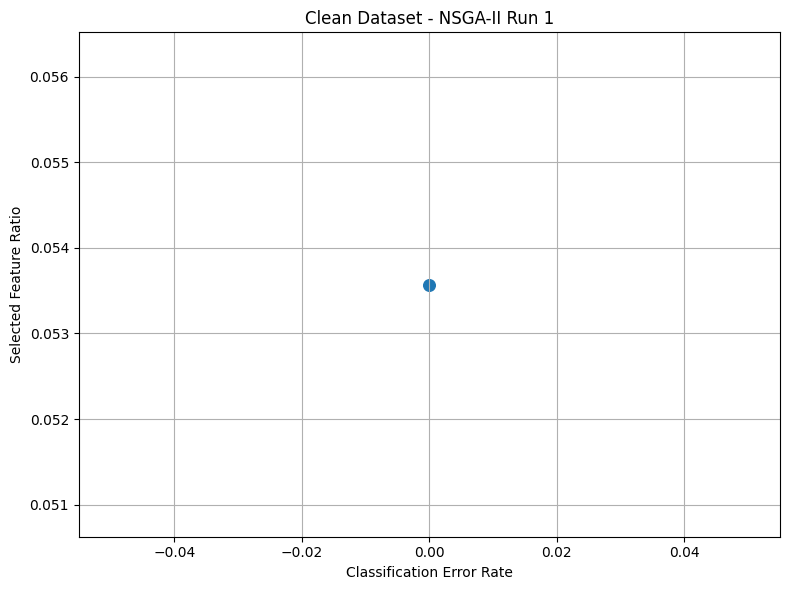


Clean Dataset - NSGA-II Run 2
Total Pareto Individuals: 2
Unique Objective Points: 1

Pareto point distribution:
Error = 0.0000, Feature Ratio = 0.0298, Number of Individuals = 2


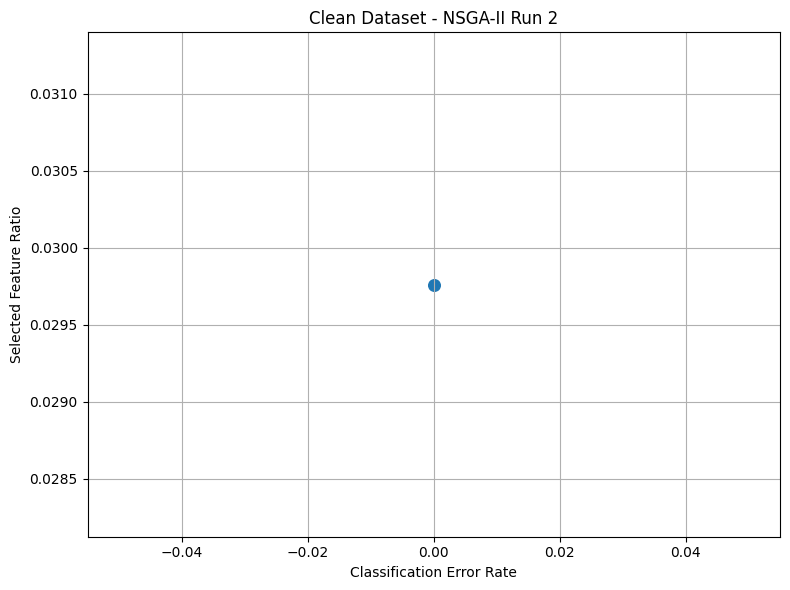


Clean Dataset - NSGA-II Run 3
Total Pareto Individuals: 50
Unique Objective Points: 2

Pareto point distribution:
Error = 0.0000, Feature Ratio = 0.0238, Number of Individuals = 48
Error = 0.0063, Feature Ratio = 0.0179, Number of Individuals = 2


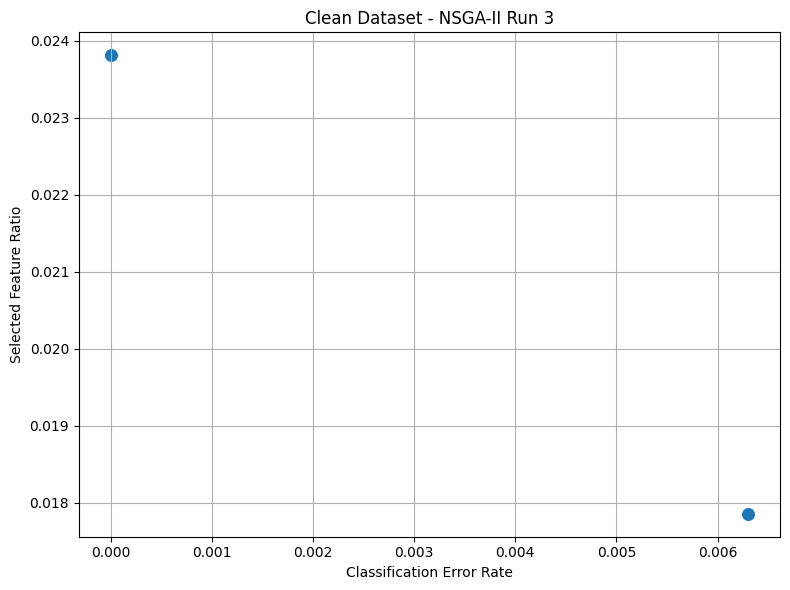

In [11]:
for run_index, pareto_front in enumerate(nsga_pareto_solutions):
    plot_objective_space(
        pareto_front,
        dataset_name = dataset_name,
        run_number=run_index + 1
    )

In [12]:
# Accuracy comparison with enire dataset

In [13]:
# Accuracy with the entire dataset
accuracy = check_accuracy_with_train_test_split(df_data, feature_list)
classification_error = 1 - accuracy
classification_error

0.0